# Para gerar gráficos e tabelas aqui, usar os arquivos que estão na pasta "dados usados no artigo" depois "rodados e guardados"

In [1]:
# =========================================================
# ANALISE DOS RESULTADOS - GOOGLE COLAB
# =========================================================

from google.colab import files
from IPython.display import display
import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# =========================================================
# UPLOAD DOS ARQUIVOS
# =========================================================

uploaded = files.upload()

Saving exp3_grupo_util7_front20_test10_obj2_lambdas50_pref0.3_mc300_dm1_resultados.csv to exp3_grupo_util7_front20_test10_obj2_lambdas50_pref0.3_mc300_dm1_resultados.csv
Saving exp3_grupo_util7_front20_test10_obj2_lambdas50_pref0.3_mc300_dm1_tempos_simulacoes.csv to exp3_grupo_util7_front20_test10_obj2_lambdas50_pref0.3_mc300_dm1_tempos_simulacoes.csv



ARQUIVOS CARREGADOS
Arquivos de resultados: 1
Arquivos de tempos:     1


exp3_grupo_util7_front20_test10_obj2_lambdas50_pref0.3_mc300_dm1
Linhas: 24000
Monte Carlos: 300
Decision makers: 1
Utilidades: ['convexa', 'linear']
UTASTAR points: [np.int64(2), np.int64(4)]
Rounds: 1 a 20
Sucessos: 24000
Falhas: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

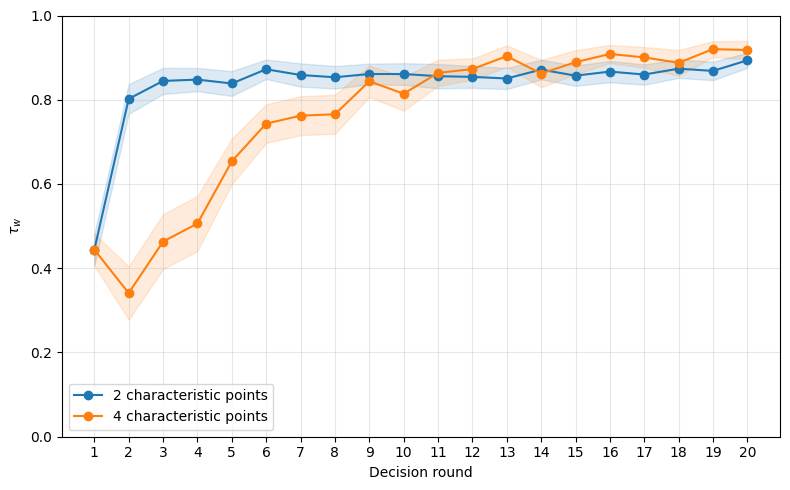

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

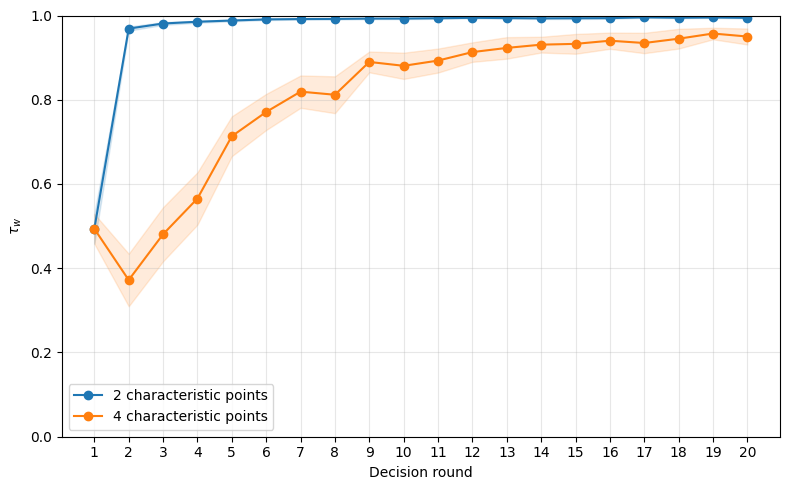

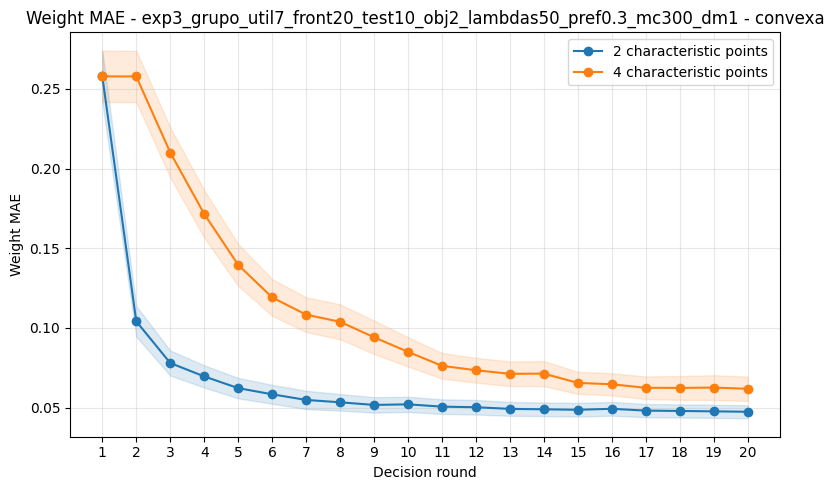

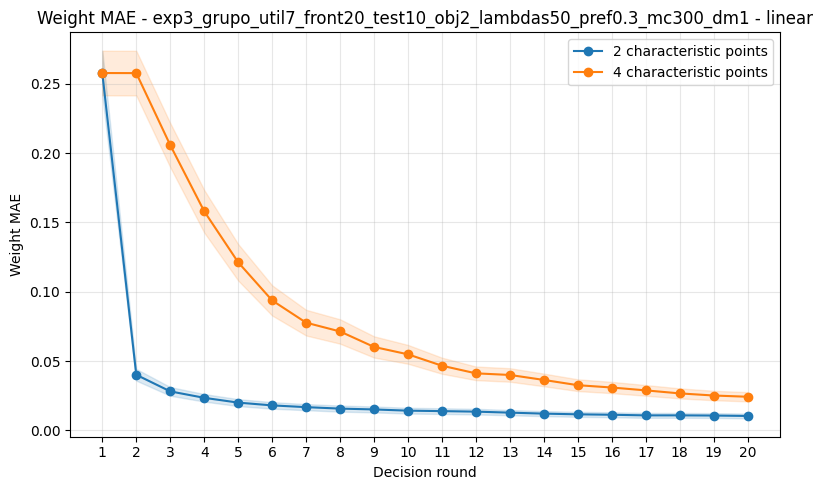

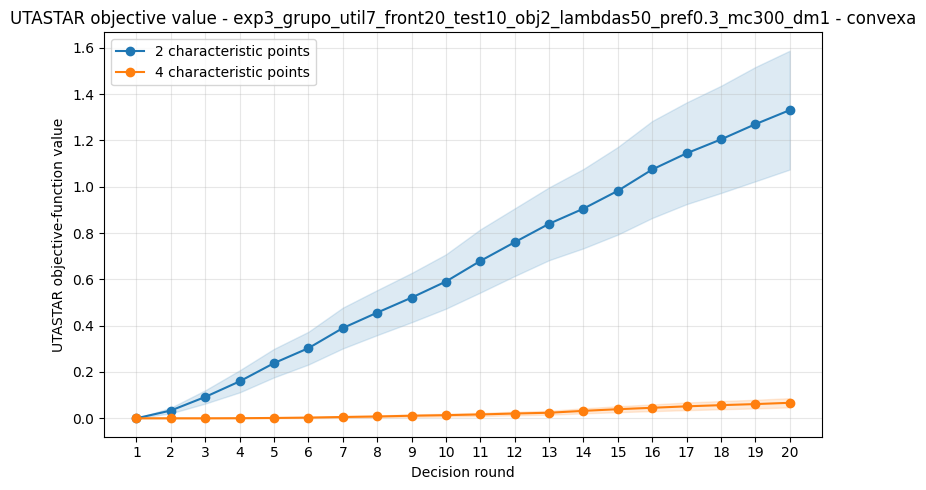

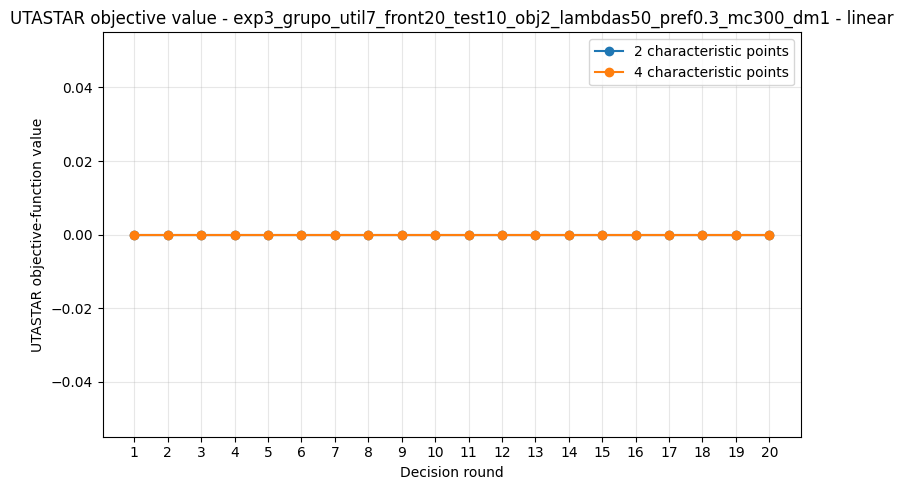

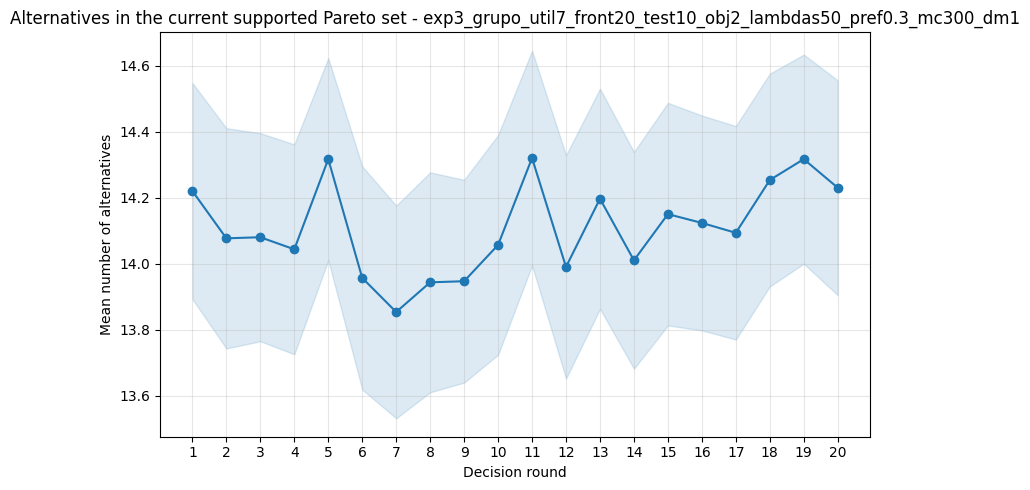

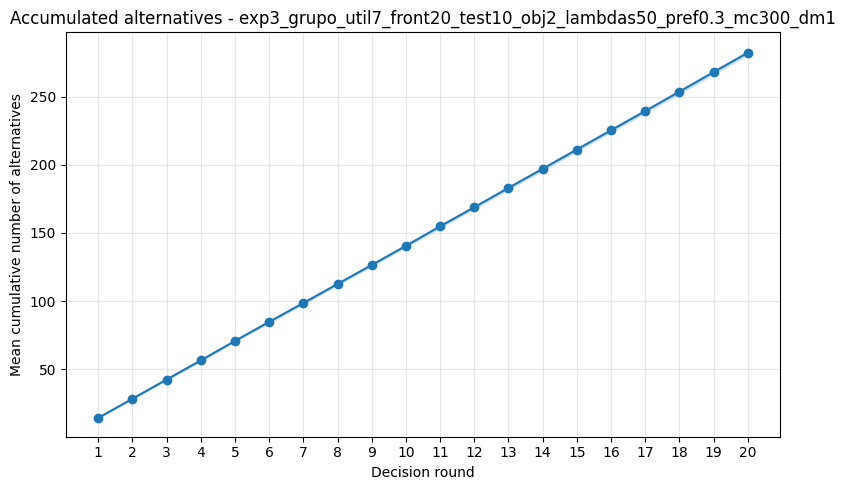

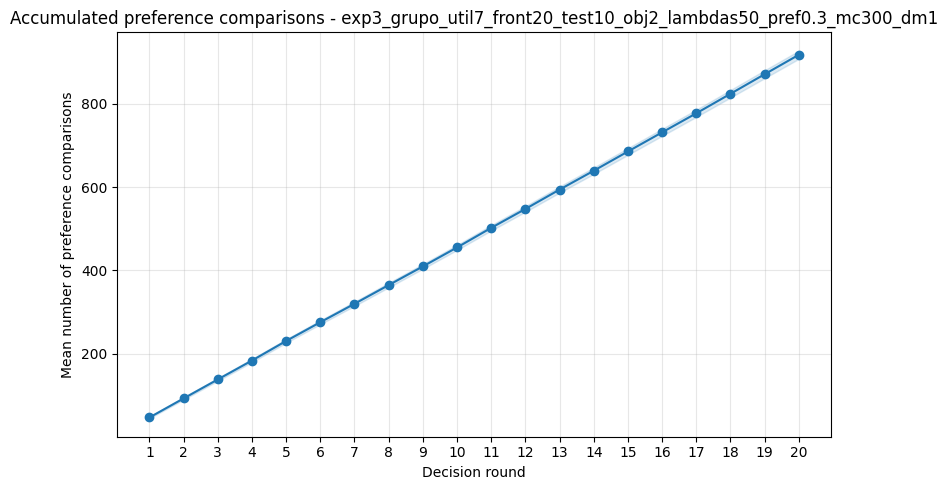

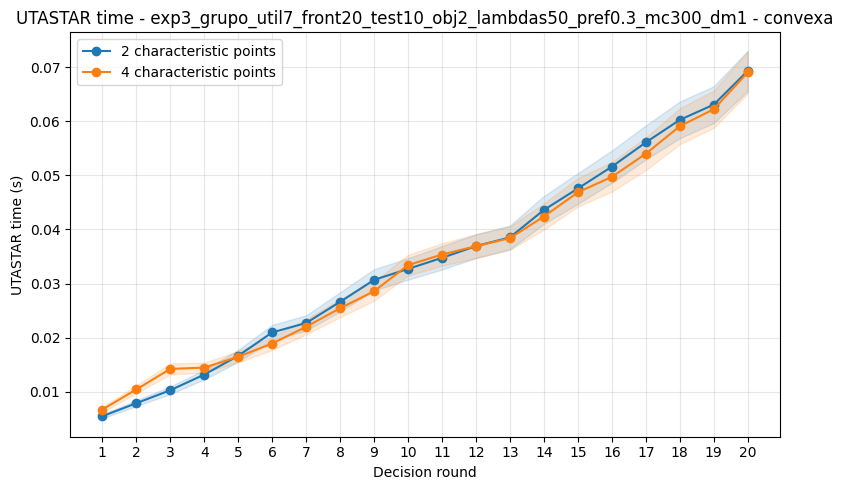

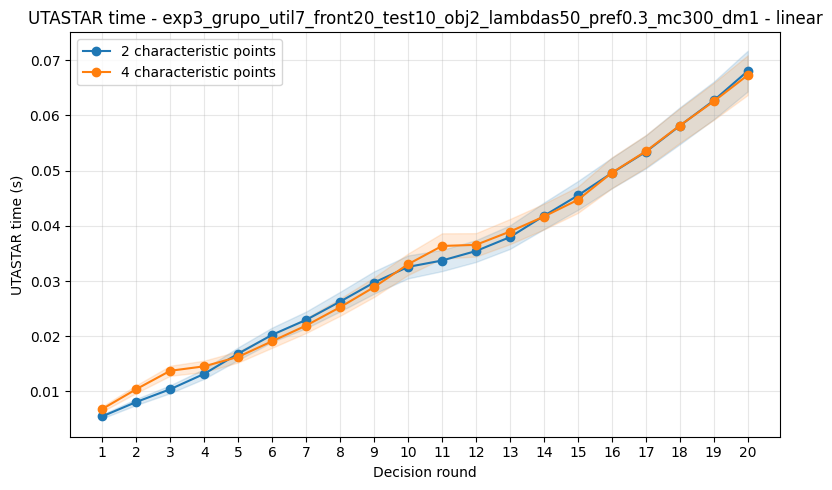

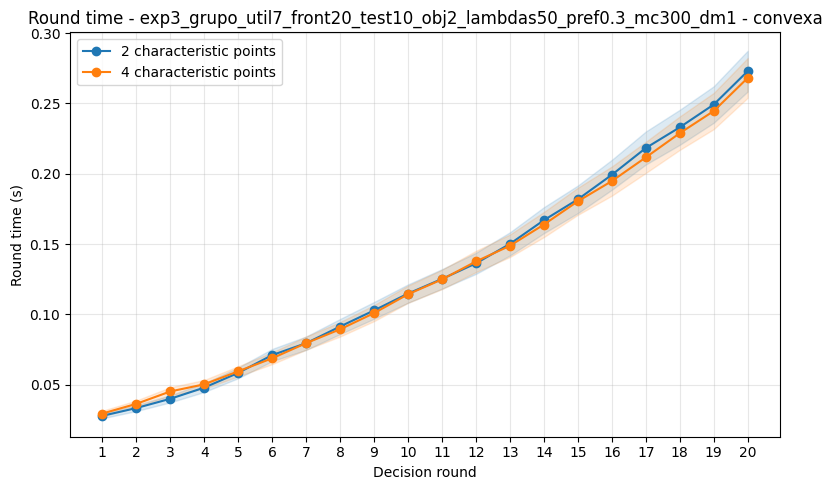

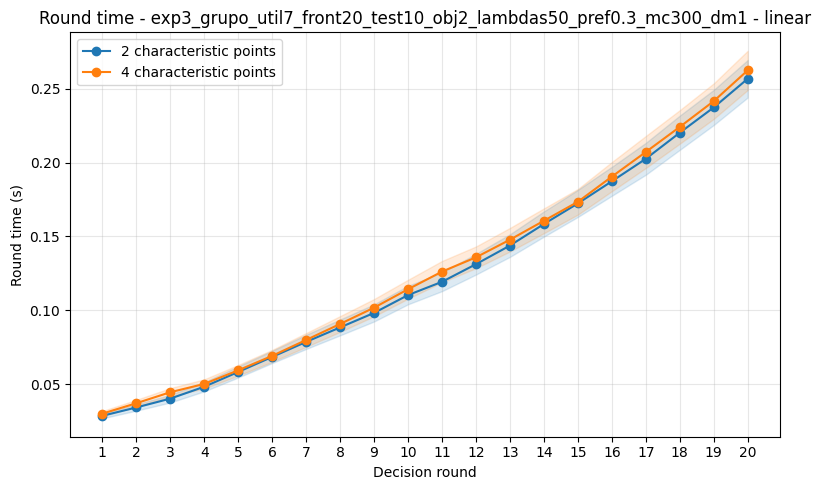

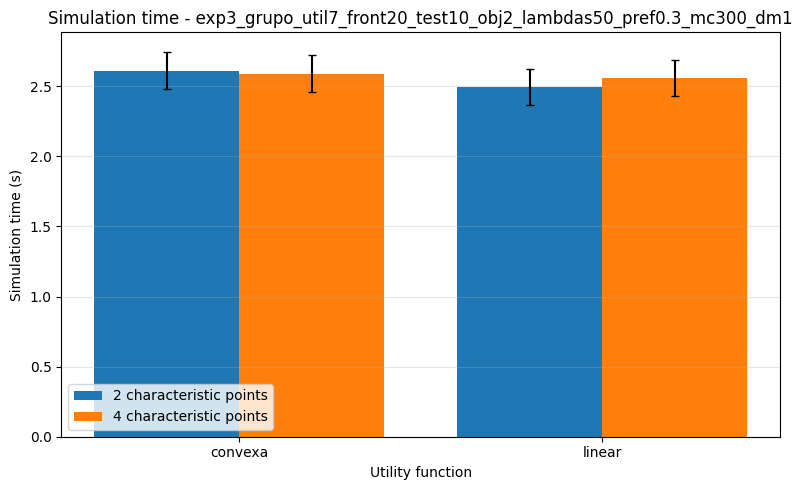


ANALISE FINALIZADA


In [3]:


# =========================================================
# CONFIGURACAO: escolha quais graficos mostrar
# =========================================================

GRAFICOS = {
    "kendall_predictive": True,
    "weight_mae": True,
    "fo_utastar": True,
    "current_alternatives": True,
    "accumulated_alternatives": True,
    "preference_comparisons": True,
    "utastar_time": True,
    "round_time": True,
    "simulation_time": True,
}

MOSTRAR_TITULOS = True
MOSTRAR_AUDITORIA = True




def normalizar_nome(nome):
    """Remove sufixos automaticos como (1), (2), ... antes de .csv."""
    return re.sub(r"\(\d+\)(?=\.csv$)", "", nome)


arquivos_resultados = {}
arquivos_tempos = {}

for nome_upload, conteudo in uploaded.items():
    nome = normalizar_nome(nome_upload)

    if nome.endswith("_resultados.csv"):
        nome_experimento = nome.removesuffix("_resultados.csv")
        arquivos_resultados[nome_experimento] = pd.read_csv(
            io.BytesIO(conteudo)
        )

    elif nome.endswith("_tempos_simulacoes.csv"):
        nome_experimento = nome.removesuffix("_tempos_simulacoes.csv")
        arquivos_tempos[nome_experimento] = pd.read_csv(
            io.BytesIO(conteudo)
        )


print("\n============================================")
print("ARQUIVOS CARREGADOS")
print("============================================")
print(f"Arquivos de resultados: {len(arquivos_resultados)}")
print(f"Arquivos de tempos:     {len(arquivos_tempos)}")

if len(arquivos_resultados) == 0:
    raise ValueError(
        "Nenhum arquivo *_resultados.csv foi identificado. "
        "Verifique os nomes dos arquivos enviados."
    )

# =========================================================
# FUNCOES AUXILIARES
# =========================================================


def media_ic95(df, grupos, coluna):
    """Media e IC95 normal: mean +/- 1.96 * SE."""
    resumo = (
        df.groupby(grupos)[coluna]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    resumo["se"] = resumo["std"] / np.sqrt(resumo["count"])
    resumo["ic95"] = 1.96 * resumo["se"]

    return resumo


def finalizar_grafico(ylabel, rounds=None, ylim=None, titulo=None, salvar=False, nome_arquivo=None):
    plt.xlabel("Decision round")
    plt.ylabel(ylabel)
    if rounds is not None: plt.xticks(rounds)
    if ylim is not None: plt.ylim(*ylim)
    if MOSTRAR_TITULOS and titulo: plt.title(titulo)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if salvar and nome_arquivo is not None:
        plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")
        files.download(nome_arquivo)
    plt.show()
    plt.close()


def plot_por_pontos(df, coluna, ylabel, titulo_base, ylim=None, salvar=False, nome_arquivo=None):


    rounds = sorted(df["iteration"].dropna().astype(int).unique())

    for tipo_utilidade in sorted(df["utility"].dropna().unique()):
        dados = df[df["utility"] == tipo_utilidade]

        plt.figure(figsize=(8, 5))

        for pontos in sorted(dados["utastar_points"].dropna().unique()):
            dados_pontos = dados[dados["utastar_points"] == pontos]

            resumo = media_ic95(
                dados_pontos,
                ["iteration"],
                coluna
            )

            linha = plt.plot(
                resumo["iteration"],
                resumo["mean"],
                marker="o",
                label=f"{int(pontos)} characteristic points"
            )[0]

            plt.fill_between(
                resumo["iteration"],
                resumo["mean"] - resumo["ic95"],
                resumo["mean"] + resumo["ic95"],
                alpha=0.15,
                color=linha.get_color()
            )

        plt.legend()



        finalizar_grafico(ylabel=ylabel, rounds=rounds, ylim=ylim, titulo=f"{titulo_base} - {tipo_utilidade}" if titulo_base else None, salvar=salvar, nome_arquivo=f"{nome_arquivo}_{tipo_utilidade}.png" if nome_arquivo else None)


def preparar_dados_da_fronteira(df, coluna):
    """
    current_alternatives, accumulated_alternatives e preference_comparisons
    sao propriedades da instancia/feedback, nao do numero de pontos UTASTAR.

    Como essas informacoes aparecem repetidas nas linhas correspondentes
    aos diferentes modelos UTASTAR (e, nos dados atuais, tambem por utility),
    mantemos uma unica observacao por Monte Carlo, DM e round.

    Se forem encontrados valores diferentes dentro da mesma combinacao,
    o codigo avisa e passa a usar a media daquela combinacao em vez de
    escolher silenciosamente um valor.
    """

    chaves = ["monte_carlo", "decision_maker", "iteration"]

    max_nunique = (
        df.groupby(chaves)[coluna]
        .nunique(dropna=False)
        .max()
    )

    if max_nunique <= 1:
        base = (
            df[chaves + [coluna]]
            .drop_duplicates(subset=chaves)
            .copy()
        )
    else:
        print(
            f"ATENCAO: '{coluna}' varia entre utility/UTASTAR points "
            "para a mesma simulacao e round. Sera usada a media por "
            "Monte Carlo, DM e round."
        )
        base = (
            df.groupby(chaves, as_index=False)[coluna]
            .mean()
        )

    return base


def plot_metrica_fronteira(df, coluna, ylabel, titulo):
    """Grafico de uma propriedade da fronteira/feedback, sem duplicar UTASTAR."""

    base = preparar_dados_da_fronteira(df, coluna)
    rounds = sorted(base["iteration"].dropna().astype(int).unique())

    resumo = media_ic95(base, ["iteration"], coluna)

    plt.figure(figsize=(8, 5))

    linha = plt.plot(
        resumo["iteration"],
        resumo["mean"],
        marker="o"
    )[0]

    plt.fill_between(
        resumo["iteration"],
        resumo["mean"] - resumo["ic95"],
        resumo["mean"] + resumo["ic95"],
        alpha=0.15,
        color=linha.get_color()
    )

    finalizar_grafico(
        ylabel=ylabel,
        rounds=rounds,
        titulo=titulo
    )


def plot_simulation_time(df_tempos, titulo_base):
    """Tempo total de simulacao: media e IC95 por utility e UTASTAR points."""

    resumo = media_ic95(
        df_tempos,
        ["utility", "utastar_points"],
        "simulation_time"
    )

    utilities = sorted(resumo["utility"].dropna().unique())
    pontos_lista = sorted(resumo["utastar_points"].dropna().unique())

    x = np.arange(len(utilities))
    largura = 0.8 / max(len(pontos_lista), 1)

    plt.figure(figsize=(8, 5))

    for i, pontos in enumerate(pontos_lista):
        sub = (
            resumo[resumo["utastar_points"] == pontos]
            .set_index("utility")
            .reindex(utilities)
        )

        deslocamento = (i - (len(pontos_lista) - 1) / 2) * largura

        plt.bar(
            x + deslocamento,
            sub["mean"],
            width=largura,
            yerr=sub["ic95"],
            capsize=3,
            label=f"{int(pontos)} characteristic points"
        )

    plt.xticks(x, utilities)
    plt.xlabel("Utility function")
    plt.ylabel("Simulation time (s)")
    plt.legend()

    if MOSTRAR_TITULOS:
        plt.title(titulo_base)

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# ANALISE DOS EXPERIMENTOS
# =========================================================

for nome_experimento, df in arquivos_resultados.items():

    partes = nome_experimento.split("_")
    obj = next(x for x in partes if x.startswith("obj"))
    lambdas = next(x for x in partes if x.startswith("lambdas"))
    pref = next(x for x in partes if x.startswith("pref"))

    print("\n\n============================================")
    print(nome_experimento)
    print("============================================")

    # -----------------------------------------------------
    # Auditoria
    # -----------------------------------------------------

    if MOSTRAR_AUDITORIA:
        print(f"Linhas: {len(df)}")
        print(f"Monte Carlos: {df['monte_carlo'].nunique()}")
        print(f"Decision makers: {df['decision_maker'].nunique()}")
        print(f"Utilidades: {sorted(df['utility'].unique())}")
        print(f"UTASTAR points: {sorted(df['utastar_points'].unique())}")
        print(
            f"Rounds: {int(df['iteration'].min())} a "
            f"{int(df['iteration'].max())}"
        )
        print(f"Sucessos: {int(df['utastar_success'].sum())}")
        print(f"Falhas: {int((~df['utastar_success']).sum())}")

    # -----------------------------------------------------
    # Weight MAE
    # -----------------------------------------------------

    colunas_reais = sorted(
        [c for c in df.columns if c.startswith("real_weight_")],
        key=lambda x: int(x.split("_")[-1])
    )

    colunas_estimadas = sorted(
        [c for c in df.columns if c.startswith("estimated_weight_")],
        key=lambda x: int(x.split("_")[-1])
    )

    erros_pesos = []

    for real, estimado in zip(colunas_reais, colunas_estimadas):
        numero = real.split("_")[-1]
        coluna_erro = f"abs_error_weight_{numero}"
        df[coluna_erro] = np.abs(df[real] - df[estimado])
        erros_pesos.append(coluna_erro)

    if erros_pesos:
        df["weight_mae"] = df[erros_pesos].mean(axis=1)

    # -----------------------------------------------------
    # 1. Predictive weighted Kendall
    # -----------------------------------------------------

    if GRAFICOS["kendall_predictive"]:
      plot_por_pontos(df=df, coluna="weighted_kendall_predictive", ylabel=r"$\tau_w$", titulo_base=None, ylim=(0, 1), salvar=True, nome_arquivo=f"kendall_{obj}_{lambdas}_{pref}")

    # -----------------------------------------------------
    # 2. Weight MAE
    # -----------------------------------------------------

    if GRAFICOS["weight_mae"] and "weight_mae" in df.columns:
        plot_por_pontos(
            df=df,
            coluna="weight_mae",
            ylabel="Weight MAE",
            titulo_base=f"Weight MAE - {nome_experimento}"
        )

    # -----------------------------------------------------
    # 3. UTASTAR objective-function value (mean)
    # -----------------------------------------------------

    if GRAFICOS["fo_utastar"]:
        plot_por_pontos(
            df=df,
            coluna="fo_utastar",
            ylabel="UTASTAR objective-function value",
            titulo_base=f"UTASTAR objective value - {nome_experimento}"
        )

    # -----------------------------------------------------
    # 4. Mean number of alternatives in the current front
    # -----------------------------------------------------

    if GRAFICOS["current_alternatives"]:
        plot_metrica_fronteira(
            df=df,
            coluna="current_alternatives",
            ylabel="Mean number of alternatives",
            titulo=(
                "Alternatives in the current supported Pareto set - "
                f"{nome_experimento}"
            )
        )

    # -----------------------------------------------------
    # 5. Mean cumulative number of alternatives
    # -----------------------------------------------------

    if GRAFICOS["accumulated_alternatives"]:
        plot_metrica_fronteira(
            df=df,
            coluna="accumulated_alternatives",
            ylabel="Mean cumulative number of alternatives",
            titulo=(
                "Accumulated alternatives - "
                f"{nome_experimento}"
            )
        )

    # -----------------------------------------------------
    # 6. Mean cumulative number of preference comparisons
    # -----------------------------------------------------

    if GRAFICOS["preference_comparisons"]:
        plot_metrica_fronteira(
            df=df,
            coluna="preference_comparisons",
            ylabel="Mean number of preference comparisons",
            titulo=(
                "Accumulated preference comparisons - "
                f"{nome_experimento}"
            )
        )

    # -----------------------------------------------------
    # 7. Mean UTASTAR time per round
    # -----------------------------------------------------

    if GRAFICOS["utastar_time"]:
        plot_por_pontos(
            df=df,
            coluna="utastar_time",
            ylabel="UTASTAR time (s)",
            titulo_base=f"UTASTAR time - {nome_experimento}"
        )

    # -----------------------------------------------------
    # 8. Mean total round time
    # -----------------------------------------------------

    if GRAFICOS["round_time"]:
        plot_por_pontos(
            df=df,
            coluna="round_time",
            ylabel="Round time (s)",
            titulo_base=f"Round time - {nome_experimento}"
        )

    # -----------------------------------------------------
    # 9. Total simulation time
    # -----------------------------------------------------

    if GRAFICOS["simulation_time"]:
        if nome_experimento in arquivos_tempos:
            plot_simulation_time(
                arquivos_tempos[nome_experimento],
                titulo_base=(
                    f"Simulation time - {nome_experimento}"
                )
            )
        else:
            print(
                "ATENCAO: arquivo de tempos correspondente "
                "nao foi enviado."
            )


print("\n============================================")
print("ANALISE FINALIZADA")
print("============================================")


In [4]:
# =========================================================
# TABELA LATEX - RESUMO DOS EXPERIMENTOS
# =========================================================

linhas = []

for nome_experimento, df in arquivos_resultados.items():

    match_obj = re.search(r"obj(\d+)", nome_experimento)
    if match_obj is None:
        continue

    n_obj = int(match_obj.group(1))

    if n_obj not in [2, 3, 4]:
        continue

    for utilidade in ["linear", "convexa"]:

        dados = df[df["utility"] == utilidade].copy()

        if dados.empty:
            continue

        # -------------------------------------------------
        # Alternativas por round
        # Remove repeticao causada pelos modelos com
        # diferentes numeros de characteristic points
        # -------------------------------------------------

        alt = (
            dados[
                ["monte_carlo", "decision_maker",
                 "iteration", "current_alternatives"]
            ]
            .drop_duplicates(
                subset=["monte_carlo", "decision_maker", "iteration"]
            )
        )

        alt_mean = alt["current_alternatives"].mean()
        alt_min  = alt["current_alternatives"].min()
        alt_max  = alt["current_alternatives"].max()
        alt_std  = alt["current_alternatives"].std()

        # -------------------------------------------------
        # Valor medio da funcao objetivo UTASTAR
        # considerando todos os rounds e configuracoes
        # -------------------------------------------------

        fo_mean = dados["fo_utastar"].mean()

        # -------------------------------------------------
        # Tempo computacional total dos 20 rounds
        # Primeiro soma os rounds de cada execucao/modelo;
        # depois calcula a media entre as execucoes
        # -------------------------------------------------

        tempos_totais = (
            dados.groupby(
                ["monte_carlo", "decision_maker", "utastar_points"]
            )["round_time"]
            .sum()
        )

        tempo_total_mean = tempos_totais.mean()

        linhas.append({
            "Objectives": n_obj,
            "Utility": utilidade,
            "Alt. mean": alt_mean,
            "Alt. min": alt_min,
            "Alt. max": alt_max,
            "Alt. std": alt_std,
            "Objective value": fo_mean,
            "Total time (s)": tempo_total_mean
        })


tabela = pd.DataFrame(linhas)

# Caso existam varios arquivos com a mesma combinacao
# objetivo × utilidade (por exemplo lambdas/pref diferentes),
# agrega essas configuracoes
tabela = (
    tabela.groupby(["Objectives", "Utility"], as_index=False)
    .agg({
        "Alt. mean": "mean",
        "Alt. min": "min",
        "Alt. max": "max",
        "Alt. std": "mean",
        "Objective value": "mean",
        "Total time (s)": "mean"
    })
)

tabela["Utility"] = tabela["Utility"].replace({
    "linear": "Linear",
    "convexa": "Convex"
})

tabela = tabela.sort_values(["Objectives", "Utility"])

display(tabela)

latex = tabela.to_latex(
    index=False,
    escape=False,
    float_format="%.4f",
    column_format="cccccccc",
    caption="Summary of the computational experiments.",
    label="tab:computational_summary"
)

print(latex)

,Objectives,Utility,Alt. mean,Alt. min,Alt. max,Alt. std,Objective value,Total time (s)
0,2,Convex,14.108833,5,24,2.877447,0.335804,2.589778
1,2,Linear,14.108833,5,24,2.877447,0.000000,2.514059


\begin{table}
\caption{Summary of the computational experiments.}
\label{tab:computational_summary}
\begin{tabular}{cccccccc}
\toprule
Objectives & Utility & Alt. mean & Alt. min & Alt. max & Alt. std & Objective value & Total time (s) \\
\midrule
2 & Convex & 14.1088 & 5 & 24 & 2.8774 & 0.3358 & 2.5898 \\
2 & Linear & 14.1088 & 5 & 24 & 2.8774 & 0.0000 & 2.5141 \\
\bottomrule
\end{tabular}
\end{table}



In [5]:
# =========================================================
# TABELAS PARA AS ANALISES SUGERIDAS PELO MATTEO
# =========================================================

# =========================================================
# TABELA 1 - 2 vs 4 CHARACTERISTIC POINTS
# =========================================================

linhas_crossover = []

for nome_experimento, df in arquivos_resultados.items():

    obj = int(re.search(r"obj(\d+)", nome_experimento).group(1))
    lambdas = int(re.search(r"lambdas(\d+)", nome_experimento).group(1))
    pref = float(re.search(r"pref([\d.]+)", nome_experimento).group(1))

    for utilidade in ["linear", "convexa"]:

        dados = df[df["utility"] == utilidade]

        if dados.empty:
            continue

        resumo = (
            dados.groupby(["iteration", "utastar_points"])
            ["weighted_kendall_predictive"]
            .mean()
            .unstack()
        )

        if 2 not in resumo.columns or 4 not in resumo.columns:
            continue

        diferenca = resumo[4] - resumo[2]

        crossover = None

        for t in diferenca.index:
            depois = diferenca.loc[diferenca.index >= t]

            if (depois >= 0).all():
                crossover = int(t)
                break

        linhas_crossover.append({
            "Objectives": obj,
            "Lambdas": lambdas,
            "Preferred group": pref,
            "Utility": utilidade,
            "Tau r1 - 2 pts": resumo.loc[1, 2],
            "Tau r1 - 4 pts": resumo.loc[1, 4],
            "Crossover round": crossover if crossover is not None else "--",
            "Tau r20 - 2 pts": resumo.loc[20, 2],
            "Tau r20 - 4 pts": resumo.loc[20, 4]
        })


tabela_crossover = pd.DataFrame(linhas_crossover)

tabela_crossover["Utility"] = tabela_crossover["Utility"].replace({
    "linear": "Linear",
    "convexa": "Convex"
})

tabela_crossover = tabela_crossover.sort_values(
    ["Objectives", "Lambdas", "Preferred group", "Utility"]
)

display(tabela_crossover)

print(
    tabela_crossover.to_latex(
        index=False,
        escape=False,
        float_format="%.3f",
        caption="Predictive performance of the two UTASTAR specifications and stable crossover round.",
        label="tab:crossover"
    )
)


# =========================================================
# TABELA 2 - INFORMACAO ACUMULADA E TEMPO COMPUTACIONAL
# =========================================================

linhas_computacional = []

for nome_experimento, df in arquivos_resultados.items():

    obj = int(re.search(r"obj(\d+)", nome_experimento).group(1))
    lambdas = int(re.search(r"lambdas(\d+)", nome_experimento).group(1))
    pref = float(re.search(r"pref([\d.]+)", nome_experimento).group(1))

    for utilidade in ["linear", "convexa"]:

        dados = df[df["utility"] == utilidade].copy()

        if dados.empty:
            continue

        # Alternativas: elimina repeticao dos modelos UTASTAR
        alt = (
            dados[
                ["monte_carlo", "decision_maker",
                 "iteration", "current_alternatives"]
            ]
            .drop_duplicates(
                subset=["monte_carlo", "decision_maker", "iteration"]
            )
        )

        yy = alt["current_alternatives"].mean()

        # Formula aproximada sugerida por Matteo
        pref_aprox_20 = 20 * (yy * pref) * ((1 - pref) * yy)

        # Round 20
        dados20 = dados[dados["iteration"] == 20].copy()

        # Comparacoes reais acumuladas no round 20
        comparacoes20 = (
            dados20[
                ["monte_carlo", "decision_maker",
                 "preference_comparisons"]
            ]
            .drop_duplicates(
                subset=["monte_carlo", "decision_maker"]
            )
        )

        # Maior tempo de resolucao UTASTAR no round 20
        idx_max = dados20["utastar_time"].idxmax()
        maior_tempo = dados20.loc[idx_max, "utastar_time"]
        pontos_maior_tempo = int(dados20.loc[idx_max, "utastar_points"])

        linhas_computacional.append({
            "Objectives": obj,
            "Lambdas": lambdas,
            "Preferred group": pref,
            "Utility": utilidade,
            "Alt. mean": yy,
            "Alt. min": alt["current_alternatives"].min(),
            "Alt. max": alt["current_alternatives"].max(),
            "Alt. std": alt["current_alternatives"].std(),
            "Approx. preferences t=20": pref_aprox_20,
            "Mean comparisons t=20": comparacoes20["preference_comparisons"].mean(),
            "Max UTASTAR time t=20 (s)": maior_tempo,
            "Points at max time": pontos_maior_tempo
        })


tabela_computacional = pd.DataFrame(linhas_computacional)

tabela_computacional["Utility"] = tabela_computacional["Utility"].replace({
    "linear": "Linear",
    "convexa": "Convex"
})

tabela_computacional = tabela_computacional.sort_values(
    ["Objectives", "Lambdas", "Preferred group", "Utility"]
)

display(tabela_computacional)

print(
    tabela_computacional.to_latex(
        index=False,
        escape=False,
        float_format="%.3f",
        caption="Size of the supported Pareto sets, accumulated preference information, and computational effort.",
        label="tab:computational_effort"
    )
)


# =========================================================
# PIOR TEMPO OBSERVADO NO ROUND 20
# =========================================================

pior = tabela_computacional.loc[
    tabela_computacional["Max UTASTAR time t=20 (s)"].idxmax()
]

print("\n============================================")
print("WORST CASE AT ROUND 20")
print("============================================")
print(f"Objectives: {pior['Objectives']}")
print(f"Lambdas: {pior['Lambdas']}")
print(f"Preferred group: {pior['Preferred group']}")
print(f"Utility: {pior['Utility']}")
print(f"UTASTAR points: {pior['Points at max time']}")
print(f"Maximum UTASTAR time: {pior['Max UTASTAR time t=20 (s)']:.4f} s")

,Objectives,Lambdas,Preferred group,Utility,Tau r1 - 2 pts,Tau r1 - 4 pts,Crossover round,Tau r20 - 2 pts,Tau r20 - 4 pts
1,2,50,0.3,Convex,0.443994,0.443994,15,0.893603,0.918135
0,2,50,0.3,Linear,0.493624,0.493624,--,0.994449,0.950111


\begin{table}
\caption{Predictive performance of the two UTASTAR specifications and stable crossover round.}
\label{tab:crossover}
\begin{tabular}{rrrlrrlrr}
\toprule
Objectives & Lambdas & Preferred group & Utility & Tau r1 - 2 pts & Tau r1 - 4 pts & Crossover round & Tau r20 - 2 pts & Tau r20 - 4 pts \\
\midrule
2 & 50 & 0.300 & Convex & 0.444 & 0.444 & 15 & 0.894 & 0.918 \\
2 & 50 & 0.300 & Linear & 0.494 & 0.494 & -- & 0.994 & 0.950 \\
\bottomrule
\end{tabular}
\end{table}



,Objectives,Lambdas,Preferred group,Utility,Alt. mean,Alt. min,Alt. max,Alt. std,Approx. preferences t=20,Mean comparisons t=20,Max UTASTAR time t=20 (s),Points at max time
1,2,50,0.3,Convex,14.108833,5,24,2.877447,836.048548,917.543333,0.211127,4
0,2,50,0.3,Linear,14.108833,5,24,2.877447,836.048548,917.543333,0.210953,4


\begin{table}
\caption{Size of the supported Pareto sets, accumulated preference information, and computational effort.}
\label{tab:computational_effort}
\begin{tabular}{rrrlrrrrrrrr}
\toprule
Objectives & Lambdas & Preferred group & Utility & Alt. mean & Alt. min & Alt. max & Alt. std & Approx. preferences t=20 & Mean comparisons t=20 & Max UTASTAR time t=20 (s) & Points at max time \\
\midrule
2 & 50 & 0.300 & Convex & 14.109 & 5 & 24 & 2.877 & 836.049 & 917.543 & 0.211 & 4 \\
2 & 50 & 0.300 & Linear & 14.109 & 5 & 24 & 2.877 & 836.049 & 917.543 & 0.211 & 4 \\
\bottomrule
\end{tabular}
\end{table}


WORST CASE AT ROUND 20
Objectives: 2
Lambdas: 50
Preferred group: 0.3
Utility: Convex
UTASTAR points: 4
Maximum UTASTAR time: 0.2111 s
